In [2]:
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 45.9 MB/s  0:00:01 eta 0:00:010:01:01


In [3]:
import pandas as pd
import numpy as np
import os
import cv2

In [4]:
df = pd.read_csv('datasets/english.csv')

In [5]:
X = []
y = []

for index, row in df.iterrows():
    img_name = row['image']
    label = row['label']

    img_path = os.path.join("datasets",img_name)
    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    image = cv2.resize(image, (64, 48))
    image = image/255.0
    image = image.flatten()
    
    X.append(image)
    y.append(label)

print(X[0:5])
print(y[0:5])

[array([1., 1., 1., ..., 1., 1., 1.], shape=(3072,)), array([1., 1., 1., ..., 1., 1., 1.], shape=(3072,)), array([1., 1., 1., ..., 1., 1., 1.], shape=(3072,)), array([1., 1., 1., ..., 1., 1., 1.], shape=(3072,)), array([1., 1., 1., ..., 1., 1., 1.], shape=(3072,))]
['0', '0', '0', '0', '0']


In [6]:
X = np.array(X)
y = np.array(y)
print("X shape:", X.shape)  # (num_samples, 784)
print("y shape:", y.shape)  # (num_samples,)

X shape: (3410, 3072)
y shape: (3410,)


In [7]:
y = pd.factorize(y)[0]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3410, 3072)
y shape: (3410,)


In [8]:
def step(z):
    return 1 if z >= 0 else -1

In [9]:
def train_perceptron(X, y_binary, lr=0.001, epochs=20, class_id=None):
    m, n = X.shape
    W = np.zeros(n)
    b = 0.1
    
    epoch_losses = []
    
    for epoch in range(epochs):
        errors = 0
        
        indices = np.random.permutation(m)
        
        for i in indices:
            xi = X[i]
            yi = y_binary[i]
            
            z = np.dot(W, xi) + b
            y_pred = 1 if z >= 0 else -1
            
            if y_pred != yi:
                W += lr * yi * xi
                b += lr * yi
                errors += 1
        
        epoch_losses.append(errors)
        
        # Early convergence
        if errors == 0:
            print(f"Converged at epoch {epoch+1}")
            break
    
    return W, b, epoch_losses

In [10]:
def train_ovr(X, y, num_classes=62, lr=0.001, epochs=20):

    classifiers = []

    for k in range(num_classes):

        print(f"\nTraining classifier for class {k}")

        # Convert labels to +1 / -1
        y_binary = np.where(y == k, 1, -1)

        W, b = train_perceptron(X, y_binary, lr, epochs, class_id = k)

        classifiers.append((W, b))

    return classifiers

In [11]:
def predict_ovr(X, classifiers):

    scores = []

    for W, b in classifiers:
        score = np.dot(X, W) + b
        scores.append(score)

    scores = np.array(scores).T  # shape: (samples, 62)

    return np.argmax(scores, axis=1)

In [12]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

In [13]:
from sklearn.model_selection import train_test_split

# X: features, y: labels
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Train samples: 2728
Test samples: 682


In [44]:
num_classes = 62
classifiers = []

for k in range(num_classes):
    # Prepare binary labels
    y_binary = np.where(y_train == k, 1, -1)
    W, b, loss = train_perceptron(X_train, y_binary, lr=0.001, epochs=20, class_id=k)
    classifiers.append((W, b))

y_pred_train = predict_ovr(X_train, classifiers)
train_acc = np.mean(y_pred_train == y_train)
print("Training Accuracy:", train_acc)

# Evaluate on test set
y_pred_test = predict_ovr(X_test, classifiers)
accuracy_test = np.mean(y_pred_test == y_test)
print("Test Accuracy:", accuracy_test)
print("Final Loss", loss)

precision_macro = precision_score(y_test, y_pred_test, average='macro')
recall_macro = recall_score(y_test, y_pred_test, average='macro')
f1_macro = f1_score(y_test, y_pred_test, average='macro')

precision_weighted = precision_score(y_test, y_pred_test, average='weighted')
recall_weighted = recall_score(y_test, y_pred_test, average='weighted')
f1_weighted = f1_score(y_test, y_pred_test, average='weighted')

print("\n===== SLP (OvR) Metrics =====")
print("Test Accuracy:", accuracy_test)

print("\n--- Macro Average ---")
print("Precision (Macro):", precision_macro)
print("Recall (Macro):", recall_macro)
print("F1-Score (Macro):", f1_macro)

print("\n--- Weighted Average ---")
print("Precision (Weighted):", precision_weighted)
print("Recall (Weighted):", recall_weighted)
print("F1-Score (Weighted):", f1_weighted)

Training Accuracy: 0.313049853372434
Test Accuracy: 0.14809384164222875
Final Loss [87, 88, 83, 84, 78, 88, 86, 86, 86, 88, 80, 86, 84, 84, 76, 85, 76, 68, 82, 72]

===== SLP (OvR) Metrics =====
Test Accuracy: 0.14809384164222875

--- Macro Average ---
Precision (Macro): 0.21120198154743638
Recall (Macro): 0.14809384164222875
F1-Score (Macro): 0.12016639055347157

--- Weighted Average ---
Precision (Weighted): 0.21120198154743638
Recall (Weighted): 0.14809384164222875
F1-Score (Weighted): 0.12016639055347156


C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [15]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # <-- do NOT fit again

# 3️⃣ Create MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(32,),  # one hidden layer with 128 neurons
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,       # optional, stops automatically if no improvement
    verbose=False
)

# 4️⃣ Train MLP
mlp.fit(X_train_scaled, y_train)

# 5️⃣ Predict and compute accuracy
y_train_pred = mlp.predict(X_train_scaled)
y_test_pred = mlp.predict(X_test_scaled)

train_accuracy = (y_train_pred == y_train).mean()
test_accuracy = (y_test_pred == y_test).mean()

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Training Accuracy: 0.7063782991202346
Test Accuracy: 0.27419354838709675


In [16]:
mlp_configs = [
    {"hidden_layer_sizes": (128,), "activation": "relu", "solver": "sgd",
     "learning_rate_init": 0.01, "batch_size": 32, "name": "Model 1"},
    
    {"hidden_layer_sizes": (256, 128), "activation": "relu", "solver": "adam",
     "learning_rate_init": 0.001, "batch_size": 64, "name": "Model 2"},
    
    {"hidden_layer_sizes": (512, 256, 128), "activation": "tanh", "solver": "adam",
     "learning_rate_init": 0.0005, "batch_size": 64, "name": "Model 3"}
]

# -----------------------------
# 4️⃣ Train and evaluate each MLP
# -----------------------------
for cfg in mlp_configs:
    print(f"Training {cfg['name']}...")
    
    mlp = MLPClassifier(
        hidden_layer_sizes=cfg["hidden_layer_sizes"],
        activation=cfg["activation"],
        solver=cfg["solver"],
        learning_rate_init=cfg["learning_rate_init"],
        batch_size=cfg["batch_size"],
        max_iter=500,
        early_stopping=True,
        verbose=False,
        random_state=42
    )
    
    # Train
    mlp.fit(X_train_scaled, y_train)
    
    # Predict
    y_train_pred = mlp.predict(X_train_scaled)
    y_test_pred = mlp.predict(X_test_scaled)
    
    # Accuracy
    train_acc = (y_train_pred == y_train).mean()
    test_acc = (y_test_pred == y_test).mean()
    
    print(f"{cfg['name']} Training Accuracy: {train_acc:.4f}")
    print(f"{cfg['name']} Test Accuracy: {test_acc:.4f}\n")

Training Model 1...
Model 1 Training Accuracy: 0.9421
Model 1 Test Accuracy: 0.3812

Training Model 2...
Model 2 Training Accuracy: 0.8365
Model 2 Test Accuracy: 0.3563

Training Model 3...
Model 3 Training Accuracy: 0.9282
Model 3 Test Accuracy: 0.3167



In [17]:
from sklearn.model_selection import GridSearchCV
mlp = MLPClassifier(max_iter=300, early_stopping=True, random_state=42)

# Define the grid
param_grid = {
    "hidden_layer_sizes": [(128,), (256,128)],
    "activation": ["relu", "tanh"],
    "solver": ["adam", "sgd"],
    "learning_rate_init": [0.001, 0.01],
    "batch_size": [32]
}

param_grid1 = {
    "hidden_layer_sizes": [(128,), (256,128)],
    "activation": ["relu", "tanh"],
    "solver": ["adam", "sgd"],
    "learning_rate_init": [0.001, 0.01],
    "batch_size": [64]
}

In [18]:
grid = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    scoring='accuracy',
    cv=2,          # 3-fold cross-validation
    n_jobs=-1,     # use all CPU cores
    verbose=2
)

In [19]:
grid1 = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid1,
    scoring='accuracy',
    cv=2,          # 3-fold cross-validation
    n_jobs=-1,     # use all CPU cores
    verbose=2
)

In [20]:
grid.fit(X_train_scaled, y_train)

# Best parameters
print("Best hyperparameters:", grid.best_params_)

# Training accuracy of best model
train_acc = grid.best_estimator_.score(X_train_scaled, y_train)

# Test accuracy
test_acc = grid.best_estimator_.score(X_test_scaled, y_test)

print("Best Model Training Accuracy:", train_acc)
print("Best Model Test Accuracy:", test_acc)

Fitting 2 folds for each of 16 candidates, totalling 32 fits


KeyboardInterrupt: 

In [ ]:
grid1.fit(X_train_scaled, y_train)

# Best parameters
print("Best hyperparameters:", grid1.best_params_)

# Training accuracy of best model
train_acc = grid1.best_estimator_.score(X_train_scaled, y_train)

# Test accuracy
test_acc = grid1.best_estimator_.score(X_test_scaled, y_test)

print("Best Model Training Accuracy:", train_acc)
print("Best Model Test Accuracy:", test_acc)

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
mlp_tuned = MLPClassifier(
    hidden_layer_sizes=(128),
    activation='relu',
    solver='sgd',
    learning_rate_init=0.01,
    batch_size=32,
    max_iter=800,
    early_stopping=True,
    random_state=42
)

In [46]:
mlp_tuned.fit(X_train_scaled, y_train)

y_train_pred = mlp_tuned.predict(X_train_scaled)
y_test_pred = mlp_tuned.predict(X_test_scaled)

In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

precision = precision_score(y_test, y_test_pred, average='macro')
recall = recall_score(y_test, y_test_pred, average='macro')
f1 = f1_score(y_test, y_test_pred, average='macro')

In [48]:
epochs_run = mlp_tuned.n_iter_
final_loss = mlp_tuned.loss_curve_[-1]

if epochs_run < mlp_tuned.max_iter:
    convergence = "Converged Early"
else:
    convergence = "Reached Max Iterations"

In [49]:
print("\n===== MLP Tuned Results =====")

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

print("Precision (Macro):", precision)
print("Recall (Macro):", recall)
print("F1-Score (Macro):", f1)

print("Epochs Run:", epochs_run)
print("Final Training Loss:", final_loss)
print("Convergence Behavior:", convergence)

print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))


===== MLP Tuned Results =====
Training Accuracy: 0.9420821114369502
Test Accuracy: 0.3812316715542522
Precision (Macro): 0.4071025524654556
Recall (Macro): 0.38123167155425214
F1-Score (Macro): 0.38018395907720626
Epochs Run: 32
Final Training Loss: 0.014243056384001342
Convergence Behavior: Converged Early

Classification Report:

              precision    recall  f1-score   support

           0       0.08      0.09      0.09        11
           1       0.23      0.45      0.30        11
           2       0.39      0.64      0.48        11
           3       0.36      0.36      0.36        11
           4       0.12      0.09      0.11        11
           5       0.30      0.27      0.29        11
           6       0.43      0.27      0.33        11
           7       0.60      0.55      0.57        11
           8       0.40      0.18      0.25        11
           9       0.71      0.45      0.56        11
          10       0.38      0.45      0.42        11
          11    

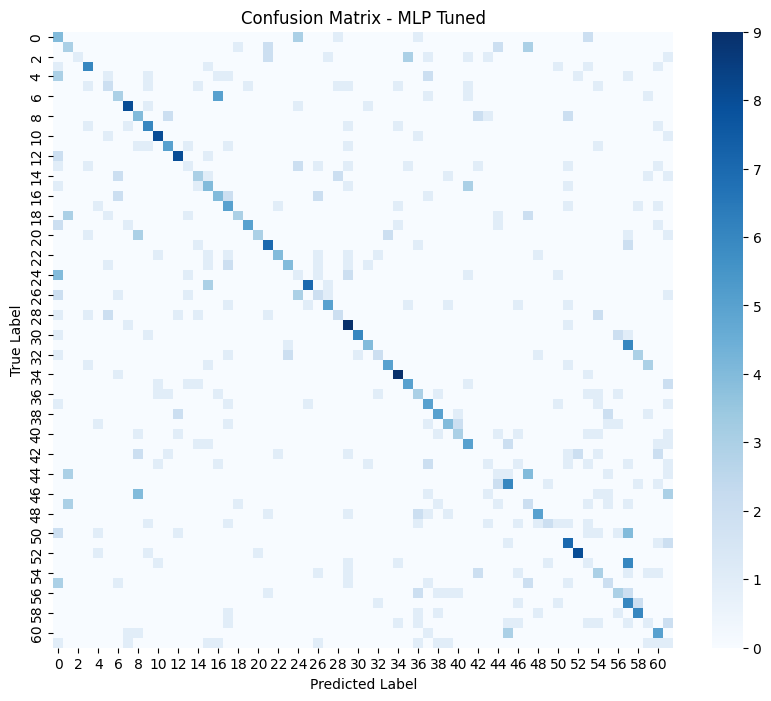

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm_mlp = confusion_matrix(y_test, y_test_pred)

# Plot
plt.figure(figsize=(10,8))
sns.heatmap(cm_mlp, cmap="Blues")
plt.title("Confusion Matrix - MLP Tuned")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.savefig("images/conf_mlp.png", dpi=300)
plt.show()

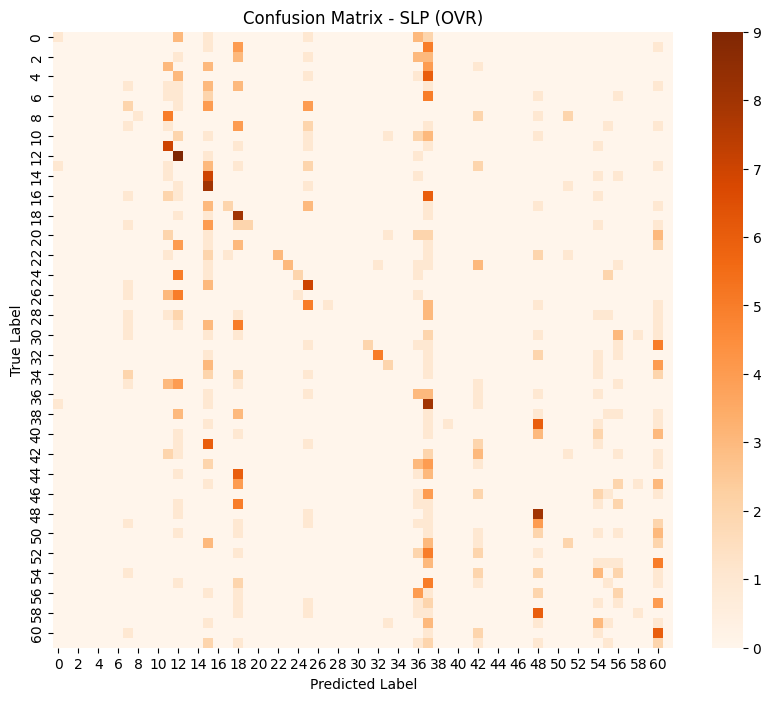

In [24]:
cm_slp = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(10,8))
sns.heatmap(cm_slp, cmap="Oranges")
plt.title("Confusion Matrix - SLP (OVR)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.savefig("images/conf_slp.png", dpi=300)

plt.show()

In [25]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

In [26]:
n_classes = len(np.unique(y_train))

# Convert labels to one-hot
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

In [27]:
y_score = mlp_tuned.predict_proba(X_test_scaled)

In [28]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

In [29]:
fpr["micro"], tpr["micro"], _ = roc_curve(
    y_test_bin.ravel(),
    y_score.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

In [30]:
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

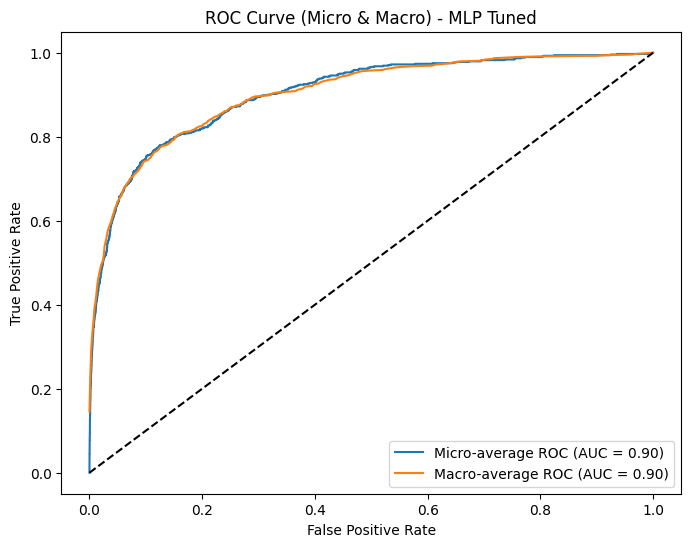

In [31]:
plt.figure(figsize=(8,6))

plt.plot(fpr["micro"], tpr["micro"],
         label=f"Micro-average ROC (AUC = {roc_auc['micro']:.2f})")

plt.plot(fpr["macro"], tpr["macro"],
         label=f"Macro-average ROC (AUC = {roc_auc['macro']:.2f})")

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Micro & Macro) - MLP Tuned")
plt.legend()
plt.savefig("images/roc_mlp.png", dpi=300)
plt.show()

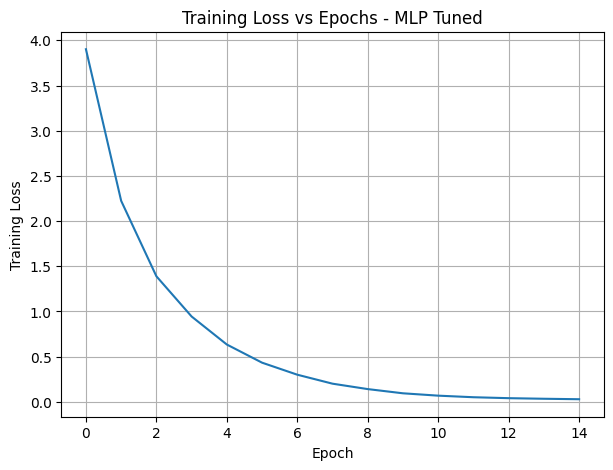

In [32]:
plt.figure(figsize=(7,5))
plt.plot(mlp_tuned.loss_curve_)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epochs - MLP Tuned")
plt.grid(True)
plt.savefig("images/trainVEpoch_MLP.png", dpi=300)
plt.show()

In [33]:
# Collect scores from all 62 classifiers
scores_list = []

for W, b in classifiers:
    scores = np.dot(X_test, W) + b
    scores_list.append(scores)

# Shape: (num_samples, 62)
y_score_slp = np.array(scores_list).T

In [34]:
from sklearn.preprocessing import label_binarize
import numpy as np

n_classes = len(np.unique(y_train))
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

In [35]:
from sklearn.metrics import roc_curve, auc

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score_slp[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

In [36]:
fpr["micro"], tpr["micro"], _ = roc_curve(
    y_test_bin.ravel(),
    y_score_slp.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

In [37]:
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

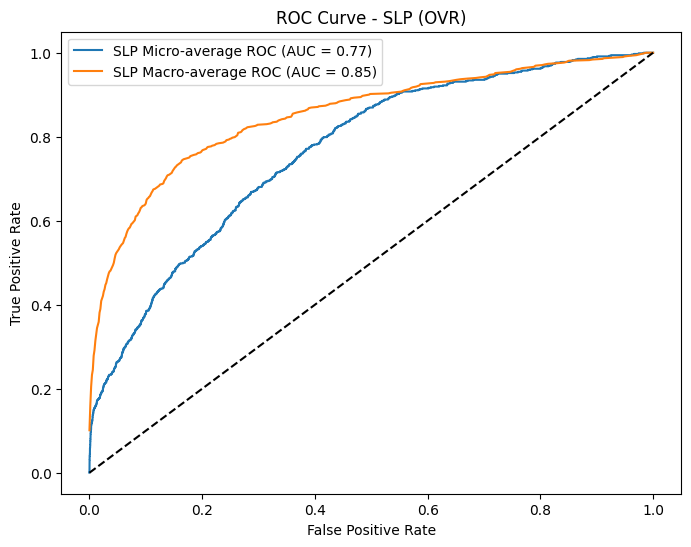

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(fpr["micro"], tpr["micro"],
         label=f"SLP Micro-average ROC (AUC = {roc_auc['micro']:.2f})")

plt.plot(fpr["macro"], tpr["macro"],
         label=f"SLP Macro-average ROC (AUC = {roc_auc['macro']:.2f})")

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SLP (OVR)")
plt.legend()
plt.savefig("images/roc_slp.png", dpi=300)
plt.show()

In [39]:
# Example: Class 0
k = 0
y_binary = np.where(y_train == k, 1, -1)

W, b, epoch_losses = train_perceptron(
    X_train, y_binary, lr=0.001, epochs=50
)

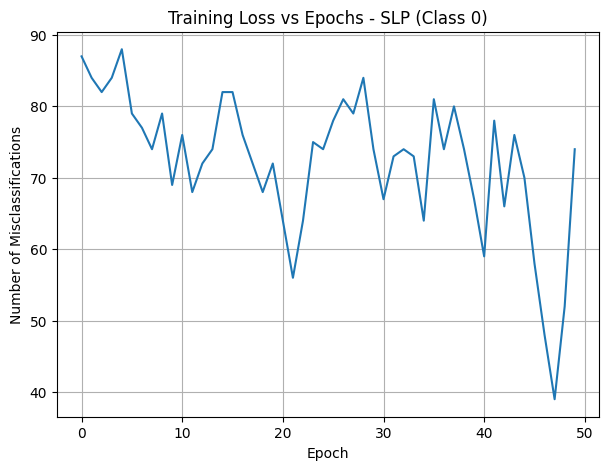

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(epoch_losses)
plt.xlabel("Epoch")
plt.ylabel("Number of Misclassifications")
plt.title("Training Loss vs Epochs - SLP (Class 0)")
plt.grid(True)
plt.savefig("images/TrainVEpoch_slp.png", dpi=300)
plt.show()